In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

import statsmodels.api as sm

import torch
import torch.nn.functional as F

import requests

from transformers import GPT2Tokenizer, GPT2LMHeadModel, logging

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
logging.set_verbosity_error()
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2-large").to(device)

model.eval();

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [25]:
num_layers = model.config.n_layer

# Implant hooks in all the expansion layers of the transformer

In [26]:
model.transformer.h[0].attn.c_attn

Conv1D(nf=3840, nx=1280)

In [27]:
# Remove old hooks if they exist
if "hook_handles" in globals() and len(hook_handles) > 0:
    for h in hook_handles:
        h.remove()

hook_handles = []
activations = {}


for layeri in range(num_layers):
    hook_name = f"attn_{layeri}"
    activations[hook_name] = None

    handle = model.transformer.h[layeri].attn.c_attn.register_forward_hook(
        lambda module, inp, out, hook_name=hook_name:
            activations.__setitem__(hook_name, out.detach())
    )

    hook_handles.append(handle)

# Get text, and identify negations and affirmations

In [28]:
# https://gutenberg.org/ebooks/32154
text = requests.get('https://gutenberg.org/cache/epub/32154/pg32154.txt').text
tokens = tokenizer.encode(text,return_tensors='pt')
num_tokens = len(tokens[0])
print(f'There are {num_tokens:,} tokens, of which {len(np.unique(tokens[0])):,} are unique.')

There are 46,971 tokens, of which 5,649 are unique.


In [29]:
# context window size (tokens before and after each target)
context_pre = 90
context_pst = 10

In [30]:
negation_words = {'not', 'cannot', 'nor', 'never'}  # set is faster for membership
isNegation = np.zeros(num_tokens, dtype=np.int8)

for ti in range(context_pre, num_tokens - context_pst):
    currtok = tokenizer.decode(tokens[0, ti]).strip().lower()
    nexttok = tokenizer.decode(tokens[0, ti + 1])

    is_contraction = any(s in currtok for s in ("n't", "'t"))
    is_exact = currtok in negation_words
    next_has_leading_space = nexttok.startswith(" ")

    if (is_contraction or is_exact) and next_has_leading_space:
        isNegation[ti] = 1

numNegationTokens = int(isNegation.sum())

In [31]:
negationsIdx = np.where(isNegation)[0]
context_win = 15

# examine some negations
print(f'There are {numNegationTokens} "negation" tokens in the dataset.\n')
for t in negationsIdx[:10]:
  print(f'Example {t}:\n{tokenizer.decode(tokens[0,t-context_win:t+context_win])}\n')

There are 217 "negation" tokens in the dataset.

Example 96:
 or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the

Example 287:
 Space Science Fiction September
    1953. Extensive research did not uncover any evidence that the
    U.S.

Example 411:
 business in the future, where the
    calculators could not handle him. He was Earth's only
    hope

Example 541:

organizer. He grinned proudly, as if personally responsible. "Not bad,
Commissioner."

"We're

Example 626:
 And nothing is actually made!
Continual improvement, but neither we nor Centaurus can stop designing
long enough to stabilize for production."

Example 1009:
 Reinhart said thoughtfully, "we would lose.
We're not far enough along to risk an overt attack." A harsh, ruthless

Example 1157:
 his own elaborately guarded office in the Security
wing. It wouldn't be long. He could practically feel the hot breath of
dest

Example 1348:
 The Centauran Empire surrounded Terra,

In [32]:
# all the negation tokens
tokenizer.decode(tokens[0,negationsIdx])

" not not notNot nor not't't not never't not't't not't notnot't not not't't Not't't notnot't't't't not not not't't't't't't't't not not not not't not't not't't not't't't't't't not't't not't't not't never't't not not't't't't't't't't't't't Not't't't't't't't't not't not't't't't not not't't not't not't Not Not'tnot't notnot not't't not't Not't't not not't't't't't't't't't't Not not't not't not't't not't't't't never't Not't not't never't't't't't't't not not not't't'tnot not not never not't't't'tNot Not not not't't't't not't't't never't not not not not not not not not not not not not not not NOT not not cannot not not not cannot not not cannot not"

In [33]:
affirmation_words = {'agree','always','allow','can','certainly','could',
                     'definitely','may','might','shall','should'}  # use set

isAffirmation = np.zeros(num_tokens, dtype=np.int8)

for ti in range(context_pre, num_tokens - context_pst):
    currtok = tokenizer.decode(tokens[0, ti]).strip().lower()
    nexttok = tokenizer.decode(tokens[0, ti + 1])

    is_exact = currtok in affirmation_words
    next_has_leading_space = nexttok.startswith(" ")
    next_is_not = nexttok.strip().lower() == "not"   # catches " not" too

    if is_exact and next_has_leading_space and (not next_is_not):
        isAffirmation[ti] = 1

numAffirmationTokens = int(isAffirmation.sum())

In [34]:
affirmationsIdx = np.where(isAffirmation)[0]
context_win = 15

# examine some examples
print(f'There are {numAffirmationTokens} "affirmation" tokens in the dataset.\n')
for t in affirmationsIdx[:10]:
  print(f'Example {t}:\n{tokenizer.decode(tokens[0,t-context_win:t+context_win])}\n')

There are 178 "affirmation" tokens in the dataset.

Example 629:
 actually made!
Continual improvement, but neither we nor Centaurus can stop designing
long enough to stabilize for production."


Example 671:
 "as soon as Terra turns out a
weapon for which Centaurus can build no defense."

"Every weapon has a defense

Example 803:
 know."

At this moment, 9:30 AM, May 7, 2136, the statistical ratio on the SRB


Example 1162:
 office in the Security
wing. It wouldn't be long. He could practically feel the hot breath of
destiny on his neck--

Example 1390:
 out.

Through the windows of his office, Reinhart could see endless
buildings and streets, Terrans hurrying back

Example 2357:
, one of these days."
Sherikov shrugged. "You can examine him, if you want. I suppose this
is what

Example 2606:
 in it."

"Wasn't it shown that nothing could travel faster than light?"

"The interstellar vid

Example 2725:
 gain mass until
its length became nil and its mass infinite. Nobody can imagine such

# Run the text through the model

In [35]:
# Create a batch for each of the token categories - negation and affirmation
batch_negations = torch.zeros((numNegationTokens, context_pre + 1 + context_pst),dtype=torch.long)
batch_affirmations = torch.zeros((numAffirmationTokens, context_pre + 1 + context_pst), dtype=torch.long)

for i in range(numNegationTokens):
  token_loc = negationsIdx[i]
  batch_negations[i, :] = tokens[0, token_loc - context_pre:token_loc + context_pst + 1]

for i in range(numAffirmationTokens):
  token_loc = affirmationsIdx[i]
  batch_affirmations[i, :] = tokens[0, token_loc - context_pre:token_loc + context_pst + 1]

print('Shape of negations batch', batch_negations.shape)
print('Shape of affirmations batch', batch_affirmations.shape)


Shape of negations batch torch.Size([217, 101])
Shape of affirmations batch torch.Size([178, 101])


In [36]:
# Process the negation batches
with torch.no_grad():
  model(batch_negations.to(device))

# copy the activations and store in a variable
negation_activations = activations.copy()

# Process the affirmation batches
with torch.no_grad():
  model(batch_affirmations.to(device))

# copy the activations and store in a variable
affirmation_activations = activations.copy()



In [37]:
activations['attn_0'].shape

torch.Size([178, 101, 3840])

# Logisitc Regression for all neurons in layer 13

In [39]:
# Create the labels
category_labels = np.hstack((np.zeros(numNegationTokens), np.ones(numAffirmationTokens)))

layer2use = 13

# Get the number of neurons
num_neurons = model.transformer.h[layer2use].attn.c_attn.weight.shape[-1]

# Initialize matrix to store the classifier results
classifier_results = np.full((num_neurons,2), np.nan)

# Loop over all neurons in layer 13
for neuroni in range(num_neurons):

  # Vectorize the activations over batches
  targets = negation_activations[f'attn_{layer2use}'][:,context_pre, neuroni].cpu().numpy()
  comparisons = affirmation_activations[f'attn_{layer2use}'][:,context_pre, neuroni].cpu().numpy()

  # Logistic Regression Classification model
  y = category_labels
  X = np.hstack((targets, comparisons))
  X = sm.add_constant(X)

  sm_model = sm.Logit(y, X)
  result = sm_model.fit(maxiter=3000, disp=0)

  # Extract p-values and t-values
  classifier_results[neuroni,0] = result.pvalues[1]
  classifier_results[neuroni,1] = result.params[1]

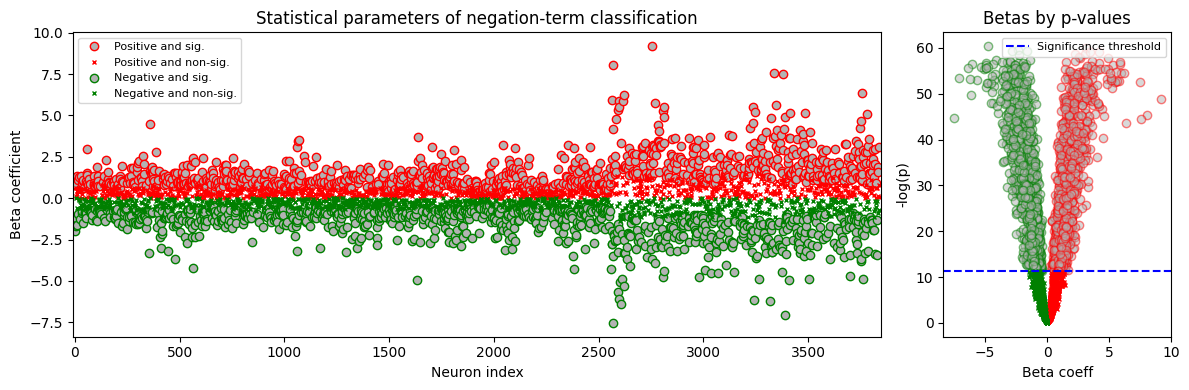

In [40]:
# visualization of model significance and sign

# setup the figure
fig = plt.figure(figsize=(12,4))
gs = GridSpec(1,4,figure=fig)

ax0 = fig.add_subplot(gs[:3])
ax1 = fig.add_subplot(gs[3])

# find the negative and positive betas, and the supra-threshold results
negBetas = classifier_results[:,1]<0
posBetas = classifier_results[:,1]>0
pvalThresh = .05/num_neurons # p<.05, Bonferroni-corrected
sigBetas = classifier_results[:,0] < pvalThresh


# positive significant betas
idx2plot = posBetas & sigBetas
ax0.plot(np.where(idx2plot)[0],classifier_results[idx2plot,1],'ro',markerfacecolor=[.7,.7,.7],label='Positive and sig.')
ax1.plot(classifier_results[idx2plot,1],-np.log(classifier_results[idx2plot,0]),'ro',markerfacecolor=[.7,.7,.7,.5])

# positive non-significant betas
idx2plot = posBetas & ~sigBetas
ax0.plot(np.where(idx2plot)[0],classifier_results[idx2plot,1],'rx',markersize=3,label='Positive and non-sig.')
ax1.plot(classifier_results[idx2plot,1],-np.log(classifier_results[idx2plot,0]),'rx',markersize=3)

# negative significant betas
idx2plot = negBetas & sigBetas
ax0.plot(np.where(idx2plot)[0],classifier_results[idx2plot,1],'go',markerfacecolor=[.7,.7,.7],label='Negative and sig.')
ax1.plot(classifier_results[idx2plot,1],-np.log(classifier_results[idx2plot,0]),'go',markerfacecolor=[.7,.7,.7,.5])

# negative non-significant betas
idx2plot = negBetas & ~sigBetas
ax0.plot(np.where(idx2plot)[0],classifier_results[idx2plot,1],'gx',markersize=3,label='Negative and non-sig.')
ax1.plot(classifier_results[idx2plot,1],-np.log(classifier_results[idx2plot,0]),'gx',markersize=3)

ax0.set(ylabel='Beta coefficient',xlabel='Neuron index',xlim=[-10,num_neurons+9],
              title='Statistical parameters of negation-term classification')
ax0.legend(fontsize=8)


ax1.axhline(-np.log(pvalThresh),linestyle='--',color='b',label='Significance threshold')
ax1.set(xlabel='Beta coeff',ylabel='-log(p)',title='Betas by p-values')
ax1.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [41]:
max_beta = np.max(classifier_results[:,1])   # this is beta, not p-value
max_beta_idx = np.where(classifier_results[:,1]==max_beta)[0][0]
max_beta_idx

np.int64(2754)

In [42]:
target = negation_activations[f'attn_{layer2use}'][:, context_pre, max_beta_idx].cpu().numpy()
comparison = affirmation_activations[f'attn_{layer2use}'][:, context_pre, max_beta_idx].cpu().numpy()

y = category_labels
X = np.hstack((target, comparison))
X = sm.add_constant(X)

sm_model_maxbeta = sm.Logit(y, X)
result_maxbeta = sm_model_maxbeta.fit(maxiter=3000, disp=0)

pred = result_maxbeta.predict(X)
acc = ((pred >= 0.5) == y).mean() * 100
print(f"Accuracy: {acc:.2f}%")

Accuracy: 91.65%


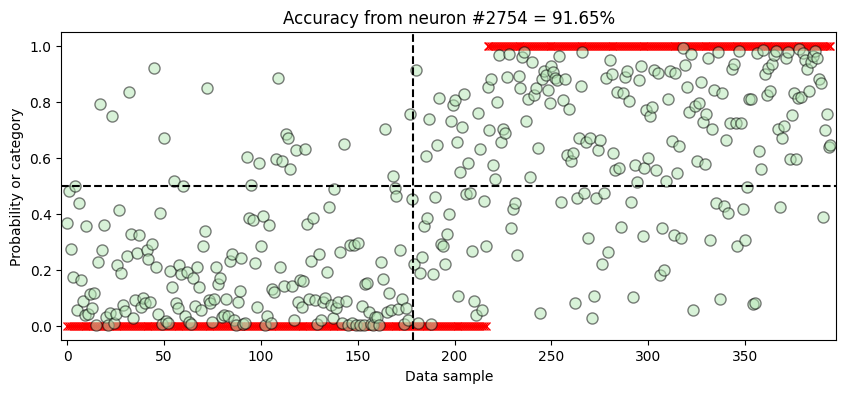

In [43]:
# visualization
plt.figure(figsize=(10,4))

plt.plot(category_labels,'rx')
plt.plot(result.predict(),'ko',markerfacecolor=[.7,.9,.7,.5],markersize=8)

plt.axvline(numAffirmationTokens+.5,linestyle='--',color='k')
plt.axhline(.5,linestyle='--',color='k')

plt.gca().set(xlabel='Data sample',ylabel='Probability or category',
              xlim=[-3,numAffirmationTokens+numNegationTokens+2],title=f'Accuracy from neuron #{max_beta_idx} = {acc:.2f}%')

plt.show()

In [44]:
min_beta_idx = np.argmin(classifier_results[:,1])
min_beta = classifier_results[min_beta_idx, 1]
min_beta_idx, min_beta

(np.int64(2570), np.float64(-7.53479421891162))

In [45]:
# scale the activity for colormapping
negActs = negation_activations[f'attn_{layer2use}'][:,:,min_beta_idx].cpu().numpy()
negActsNorm = (negActs - negActs.min()) / (negActs.max()-negActs.min())

In [46]:
# all of this code is copied from several previous code files
fig,ax = plt.subplots(figsize=(10,2))
temp_text = ax.text(0,0,'n',fontsize=12,fontfamily='monospace')
bbox = temp_text.get_window_extent(renderer=fig.canvas.get_renderer())
inv = ax.transAxes.inverted()
bbox_axes = inv.transform([[bbox.x0,bbox.y0], [bbox.x1,bbox.y1]])
en_width = bbox_axes[1,0] - bbox_axes[0,0] # bbox is [(x0,y0),(x1,y1)]
plt.close(fig)

) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


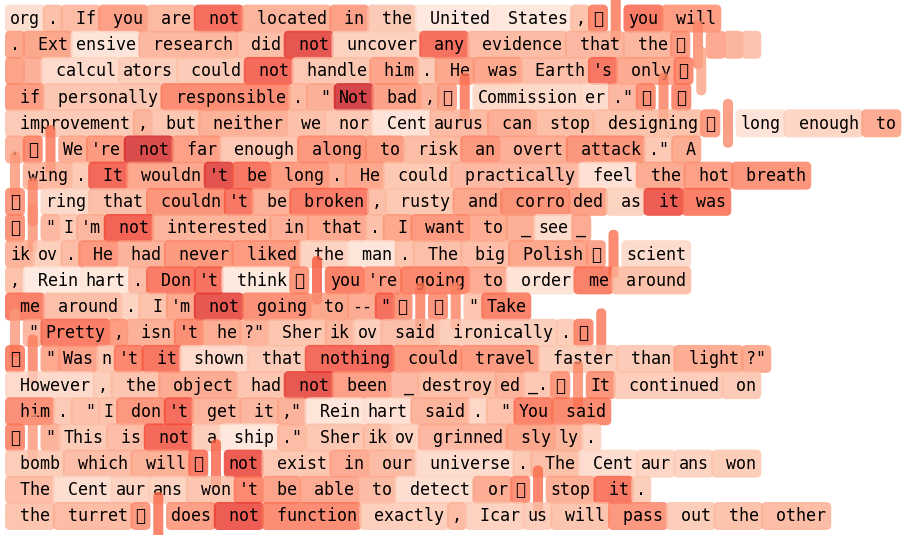

In [47]:
x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, ax = plt.subplots(figsize=(10,2))
ax.axis('off')


# loop over rows in the batch
for batchi in range(20): # just the first 20 sequences

  for toki in range(context_pre-5,batch_negations.shape[1]):

    # text of this token
    toktext = tokenizer.decode([batch_negations[batchi,toki]])

    # width of the token
    token_width = en_width*len(toktext)

    # text object with background color matching the activation
    ax.text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
            bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Reds(negActsNorm[batchi,toki]**2), edgecolor='none', alpha=.8))

    # update the token counter and x_pos
    x_pos += token_width + .01 # plus a small gap

  # end of the line; reset coordinates and counter
  y_pos -= .17
  x_pos = 0

plt.show()

# Laminar profile of classification

In [49]:
# initialize matrix to store the classifier results
pvalues  = np.ones((model.config.n_layer,num_neurons)) # initialize to 1's to ignore in subsequent mask
betas    = np.zeros((model.config.n_layer,num_neurons))
accuracy = np.zeros((model.config.n_layer,num_neurons))


# loop over layers
for layeri in range(model.config.n_layer):

  # loop over neurons for per-neuron analysis
  for neuroni in range(num_neurons):
    # vectorize the activations over batches
    targs = negation_activations[f'attn_{layeri}'][:,context_pre,neuroni].cpu().numpy()
    comps = affirmation_activations[f'attn_{layeri}'][:,context_pre,neuroni].cpu().numpy()

    # build and run the model
    feat = np.hstack((targs, comps)).astype(np.float64)

    # Check for zero standard deviation to prevent singular matrix error
    if np.std(feat) == 0:
      # If no variance, neuron is not informative, assign default non-significant values
      pvalues[layeri,neuroni] = 1.0
      betas[layeri,neuroni] = 0.0
      accuracy[layeri,neuroni] = 50.0 # Random chance for binary classification
      continue # Skip to the next neuron

    feat = (feat - feat.mean()) / (feat.std() + 1e-12)   # z-score
    X = sm.add_constant(feat)

    try:
      result = sm.Logit(category_labels,X).fit_regularized(maxiter=3000,disp=0, alpha=0.1)

      # extract the results (p-value, beta, and accuracy)
      pvalues[layeri,neuroni]  = result.pvalues[1]
      betas[layeri,neuroni]    = result.params[1]
      accuracy[layeri,neuroni] = 100*((result.predict()>.5)==category_labels).mean()
    except np.linalg.LinAlgError:
      # Handle cases where fit_regularized might still fail even after checking std
      pvalues[layeri,neuroni] = 1.0
      betas[layeri,neuroni] = 0.0
      accuracy[layeri,neuroni] = 50.0

  print(f'Finished layer {layeri+1:2}/{model.config.n_layer}')

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Finished layer  1/36
Finished layer  2/36


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Finished layer  3/36
Finished layer  4/36


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


...

Finished layer  6/36


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Finished layer  7/36
Finished layer  8/36


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Finished layer  9/36
Finished layer 10/36
Finished layer 11/36
Finished layer 12/36
Finished layer 13/36
Finished layer 14/36
Finished layer 15/36
Finished layer 16/36
Finished layer 17/36
Finished layer 18/36
Finished layer 19/36
Finished layer 20/36
Finished layer 21/36
Finished layer 22/36
Finished layer 23/36
Finished layer 24/36
Finished layer 25/36
Finished layer 26/36
Finished layer 27/36
Finished layer 28/36
Finished layer 29/36
Finished layer 30/36
Finished layer 31/36
Finished layer 32/36
Finished layer 33/36
Finished layer 34/36
Finished layer 35/36
Finished layer 36/36


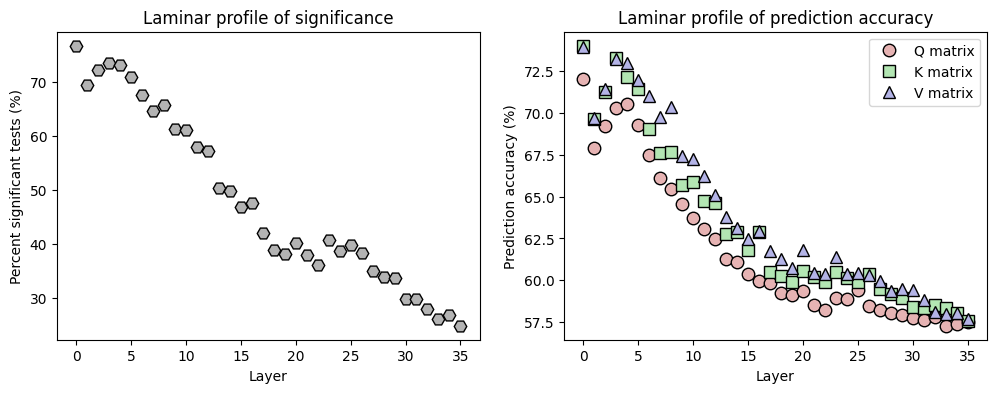

In [53]:
# create two masks
pvalue_mask = pvalues<.05/num_neurons
posbet_mask = betas>0

# get accuracy only from masked neurons
masked_accuracy = np.ma.masked_where(~(pvalue_mask & posbet_mask),accuracy)

q, k, v = torch.tensor(masked_accuracy, dtype=torch.long).split(model.config.n_embd, dim=1)

# make the plot
_,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(100*np.mean(pvalue_mask,axis=1),'kH',markerfacecolor=[.7,.7,.7],markersize=9)
axs[0].set(xlabel='Layer',ylabel='Percent significant tests (%)',title='Laminar profile of significance')

axs[1].plot(np.mean(q.cpu().numpy(),axis=1),'ko',markerfacecolor=[.9,.7,.7],markersize=9,label='Q matrix')
axs[1].plot(np.mean(k.cpu().numpy(),axis=1),'ks',markerfacecolor=[.7,.9,.7],markersize=9,label='K matrix')
axs[1].plot(np.mean(v.cpu().numpy(),axis=1),'k^',markerfacecolor=[.7,.7,.9],markersize=9,label='V matrix')
axs[1].legend()

axs[1].set(xlabel='Layer',ylabel='Prediction accuracy (%)',title='Laminar profile of prediction accuracy')
plt.show()